# Bone Marrow Olink

In [1]:
## Load Libraries installed from 'add_R_packages.txt'
library(hise)
library(magrittr)
library(tidyverse)
library(data.table)
library(readxl)
library(naniar)
library(visdat)
library(janitor)
library(skimr)
library(ggridges)
library(ggpubr)
library(broom)
library(car)
library(gt)
library(gtExtras)
library(gtsummary)
library(knitr)  
library(logger)
library(OlinkAnalyze)
library(devtools)
suppressPackageStartupMessages(library(ComplexHeatmap))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract()   masks magrittr::extract()
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::lag()       masks stats::lag()
✖ purrr::set_names() masks magrittr::set_names()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘janitor’


The foll

Loading required package: carData




Attaching package: ‘car’




The following object is masked from ‘package:dplyr’:

    recode




The following object is masked from ‘package:purrr’:

    some




Loading required package: usethis



In [2]:
### Load internal helper function libraries 
### that were custom made for this project
source('../00-utilities/functions/00_functions_data_loading.R')
file.sources <- list.files(
    path = "./ndmmFH1_helper_functions", 
    pattern = "\\.R$", full.names = TRUE
)
file.sources
# Source each R file
invisible(sapply(file.sources, source))

[1] "./ndmmFH1_helper_functions/data_crud.R" 
[2] "./ndmmFH1_helper_functions/data_manip.R"
[3] "./ndmmFH1_helper_functions/data_vis.R"  
[4] "./ndmmFH1_helper_functions/misc.R"      
[5] "./ndmmFH1_helper_functions/static.R"

## Local Helper Code

This code will make it easier for general changes after the exact definition and filtering of samples has been done. 

In [3]:
filter_samples <- function(df) {
  if(! is.element("Sample_Type", names(df))) {
    stop("Sample_Type not in the df provided")
  }
  df <- df %>% filter(Sample_Type == "SAMPLE")
  if(nrow(df) == 0) {
    stop("Unexpected empty df after filtering for samples")
  }
  df
  
}

## Download Olink files from HISE

In [4]:
data.handle <- downloadFiles(list('628523de-7712-4668-a93b-787d859be647',
                                  '23e27aa1-0346-44a6-aa74-f9ddc3dee8c1'))

[1] "downloading fileID 628523de-7712-4668-a93b-787d859be647"
[1] "downloading fileID 23e27aa1-0346-44a6-aa74-f9ddc3dee8c1"


In [5]:
getFileNames(data.handle)

[1] "/home/workspace/input/4095849279/FH_MM_Year4/628523de-7712-4668-a93b-787d859be647/AIFI-2023-12-14T00:33:11.023028764Z/Q-11665_Skene_NPX_2023-12-05.xlsx"
[2] "/home/workspace/input/4095849279/FH_MM_Year4/23e27aa1-0346-44a6-aa74-f9ddc3dee8c1/Q-17067_olink_bridged_results_Dec2024.csv"

## Load Data

In [6]:
data.batch1 <- getFileNames(data.handle)[1] %>% readxl::read_xlsx()
data.batch2 <- getFileNames(data.handle)[2] %>% read.csv()

In [7]:
dim(data.batch1)
head(data.batch1, 2)

[1] 500310     16

SampleID,Sample_Type,Index,OlinkID,UniProt,Assay,MissingFreq,Panel,Panel_Lot_Nr,PlateID,QC_Warning,LOD,NPX,Normalization,Assay_Warning,ExploreVersion
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dttm>
BMIF02603-001-001,SAMPLE,1,OID21161,P22307,SCP2,0.753,Oncology,B23406,Q-11665_SS230887,PASS,0.4143,0.4607,Intensity,PASS,2001-03-08
BMIF02604-001-003,SAMPLE,2,OID21161,P22307,SCP2,0.753,Oncology,B23406,Q-11665_SS230887,PASS,0.4143,-0.0194,Intensity,PASS,2001-03-08


In [8]:
dim(data.batch2)
head(data.batch2, 2)

[1] 382200     51

,V1,SampleID,SampleType,WellID,PlateID_qry,DataAnalysisRefID,OlinkID,UniProt,Assay,AssayType,⋯,LOD_ref,QC_Warning_ref,PlateID_ref,submission_ref,SampleWarningBridge,N_Bridge,BatchOffset,NPX_bridged,LOD_bridged,BridgingDetails
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,1,BMIF04992-001-005,SAMPLE,A1,Q-17067_SS240310,E70006,OID20049,P16860,NPPB,assay,⋯,NA,NA,NA,NA,Pass,19,-0.2357203,4.3532775,3.207401,"Bridged to submission Q-11665 by median offset, warned samples excluded on per-assay basis"
2,2,BMIF04438-001-005,SAMPLE,A2,Q-17067_SS240310,E70006,OID20049,P16860,NPPB,assay,⋯,NA,NA,NA,NA,Pass,19,-0.2357203,0.1225458,3.207401,"Bridged to submission Q-11665 by median offset, warned samples excluded on per-assay basis"


In [9]:
colnames(data.batch1)
colnames(data.batch2)

[1] "SampleID"       "Sample_Type"    "Index"          "OlinkID"       
 [5] "UniProt"        "Assay"          "MissingFreq"    "Panel"         
 [9] "Panel_Lot_Nr"   "PlateID"        "QC_Warning"     "LOD"           
[13] "NPX"            "Normalization"  "Assay_Warning"  "ExploreVersion"

[1] "V1"                  "SampleID"            "SampleType"         
 [4] "WellID"              "PlateID_qry"         "DataAnalysisRefID"  
 [7] "OlinkID"             "UniProt"             "Assay"              
[10] "AssayType"           "Panel"               "Block"              
[13] "Count"               "ExtNPX"              "NPX_qry"            
[16] "Normalization"       "PCNormalizedNPX"     "Assay_Warning"      
[19] "QC_Warning_qry"      "ExploreVersion"      "LOD_qry"            
[22] "PCNormalizedLOD"     "Index"               "Well"               
[25] "Is_plate_control"    "Row"                 "Column"             
[28] "Dilution"            "DilutionGroup"       "AssayLabel"         
[31] "UniqueAssay"         "PlateMap"            "UniqueSampleID"     
[34] "is_bridge_contol"    "submission_qry"      "Manual_QC_Flag"     
[37] "Manual_QC_Note"      "SampleID_ref"        "SampleID_query"     
[40] "sample_origin"       "NPX_ref"             "LOD_ref"            
[43] "QC_Warning_ref"      "PlateID_ref"         "submission_ref"     
[46] "SampleWarningBridge" "N_Bridge"            "BatchOffset"        
[49] "NPX_bridged"         "LOD_bridged"         "BridgingDetails"

# Data Transformations

## Re-annotate batch 2 with samplekitGUID 
Notably, batch 2 is missing sampleKitGUID column. Add this back with functions in olink-qc-report

In [10]:
batch2annotated <- format_olink_metadata(
    hise_fileid =  "23e27aa1-0346-44a6-aa74-f9ddc3dee8c1", # Batch 2, bridged and tagged
    fileType = "BridgedOlink#ProjectStore",
    keep_values = c(
      SampleID = "specimen.specimenGuid",
      Cohort = "cohort.cohortGuid",
      Subject = "subject.subjectGuid",
      Sex = "subject.biologicalSex",
      VisitName = "sample.visitName",
      VisitDetails = "sample.visitDetails",
      DaysSinceFirstVisit = "sample.daysSinceFirstVisit",
      SampleKitGuid = "sample.sampleKitGuid"
    ),
    alt_fileid = "47b9ed76-6b73-4895-a316-f774559d29cb", # Raw Batch 2, pre-bridging
    alt_fileType = "Olink",
    sep=","
)

150 unique specimen IDs in file
Found 150 specimen IDs that match file
No metadata for 0 specimen IDs in file


In [11]:
dim(batch2annotated)
head(batch2annotated,3)

[1] 150   8

,SampleID,Cohort,Subject,Sex,VisitName,VisitDetails,DaysSinceFirstVisit,SampleKitGuid
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,BMIF02609-001-005,FH2,FH2004,Female,Other - Non-Flu,MM CD38 Pre-treatment,0,KT02609
2,BMIF02609-001-006,FH2,FH2004,Female,Other - Non-Flu,MM CD38 Pre-treatment,0,KT02609
3,BMIF02609-001-004,FH2,FH2004,Female,Other - Non-Flu,MM CD38 Pre-treatment,0,KT02609


In [12]:
batch2annotated_distinct <- batch2annotated %>% distinct(SampleID, .keep_all = TRUE)

In [13]:
data.batch2 <- dplyr::inner_join(
    data.batch2,
    batch2annotated_distinct,
    by="SampleID",
    relationship = "many-to-one")

In [14]:
dim(data.batch2)
head(data.batch2,2)

[1] 382200     58

,V1,SampleID,SampleType,WellID,PlateID_qry,DataAnalysisRefID,OlinkID,UniProt,Assay,AssayType,⋯,NPX_bridged,LOD_bridged,BridgingDetails,Cohort,Subject,Sex,VisitName,VisitDetails,DaysSinceFirstVisit,SampleKitGuid
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,BMIF04992-001-005,SAMPLE,A1,Q-17067_SS240310,E70006,OID20049,P16860,NPPB,assay,⋯,4.3532775,3.207401,"Bridged to submission Q-11665 by median offset, warned samples excluded on per-assay basis",FH2,FH2007,Male,Other - Non-Flu,MM CD38 12 months,382,KT04992
2,2,BMIF04438-001-005,SAMPLE,A2,Q-17067_SS240310,E70006,OID20049,P16860,NPPB,assay,⋯,0.1225458,3.207401,"Bridged to submission Q-11665 by median offset, warned samples excluded on per-assay basis",FH2,FH2008,Female,Other - Non-Flu,MM CD38 8 weeks,86,KT04438


## Annotate and format columns in batch 1

In [15]:
# '628523de-7712-4668-a93b-787d859be647'

batch1annotated <- format_olink_metadata(
    hise_fileid =  '628523de-7712-4668-a93b-787d859be647', # Batch 1, bridged
    keep_values = c(
      SampleID = "specimen.specimenGuid",
      Cohort = "cohort.cohortGuid",
      Subject = "subject.subjectGuid",
      Sex = "subject.biologicalSex",
      VisitName = "sample.visitName",
      VisitDetails = "sample.visitDetails",
      DaysSinceFirstVisit = "sample.daysSinceFirstVisit",
      SampleKitGuid = "sample.sampleKitGuid"
    ),
    fileType = "Olink",
    sep=","
)

178 unique specimen IDs in file
Found 166 specimen IDs that match file
No metadata for 12 specimen IDs in file: [CONTROL_SAMPLE_US_CS_AS_3-1,CONTROL_SAMPLE_US_CS_AS_3-2,CONTROL_SAMPLE_US_CS_AS_3-11,CONTROL_SAMPLE_US_CS_AS_3-12,CONTROL_SAMPLE_US_CS_AS_3-7,CONTROL_SAMPLE_US_CS_AS_3-8,CONTROL_SAMPLE_US_CS_AS_3-3,CONTROL_SAMPLE_US_CS_AS_3-4,CONTROL_SAMPLE_US_CS_AS_3-5,CONTROL_SAMPLE_US_CS_AS_3-6,CONTROL_SAMPLE_US_CS_AS_3-9,CONTROL_SAMPLE_US_CS_AS_3-10]


In [16]:
batch1annotated_distinct <- batch1annotated %>% distinct(SampleID, .keep_all = TRUE)

In [17]:
data.batch1 <- dplyr::left_join(
    data.batch1,
    batch1annotated_distinct,
    by="SampleID",
    relationship = "many-to-one")

In [23]:
## Examine dimensions & an illustrative example 
dim(data.batch1)
head(data.batch1[data.batch1$Assay=='SLAMF7',]) %>% t

[1] 500310     23

SampleID,BMIF02603-001-001,BMIF02604-001-003,SUP02433-001-003,SUP02438-001-003,BMIF04753-001-001,BMIF02617-001-001
Sample_Type,SAMPLE,SAMPLE,SAMPLE,SAMPLE,SAMPLE,SAMPLE
Index,1,2,3,4,6,7
OlinkID,OID20602,OID20602,OID20602,OID20602,OID20602,OID20602
UniProt,Q9NQ25,Q9NQ25,Q9NQ25,Q9NQ25,Q9NQ25,Q9NQ25
Assay,SLAMF7,SLAMF7,SLAMF7,SLAMF7,SLAMF7,SLAMF7
MissingFreq,0.2711,0.2711,0.2711,0.2711,0.2711,0.2711
Panel,Inflammation,Inflammation,Inflammation,Inflammation,Inflammation,Inflammation
Panel_Lot_Nr,E50006,E50006,E50006,E50006,E50006,E50006
PlateID,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887,Q-11665_SS230887
QC_Warning,PASS,PASS,PASS,PASS,PASS,PASS


## Remove FH1 Samples from Batch 2, to remove potential Batch effects in FH1

In [24]:
table(data.batch2$Cohort)
data.batch2 <- data.batch2[data.batch2$Cohort!="FH1",]
table(data.batch2$Cohort)


AllCells      FH1      FH2 
   76440   168168   137592 


AllCells      FH2 
   76440   137592 

## (Optional) Filter Batch 1 & Batch 2 to have the same Columns

In [25]:
common_cols <- intersect(colnames(data.batch1), colnames(data.batch2))
length(common_cols)
common_cols

[1] 16

[1] "SampleID"            "Index"               "OlinkID"            
 [4] "UniProt"             "Assay"               "Panel"              
 [7] "Normalization"       "Assay_Warning"       "ExploreVersion"     
[10] "Cohort"              "Subject"             "Sex"                
[13] "VisitName"           "VisitDetails"        "DaysSinceFirstVisit"
[16] "SampleKitGuid"

In [21]:
# data.batch1 = data.batch1[,common_cols]
# data.batch2 = data.batch2[,common_cols]

# dim(data.batch1)
# dim(data.batch2)

## Data Typing

In [26]:
head(data.batch1,2)

SampleID,Sample_Type,Index,OlinkID,UniProt,Assay,MissingFreq,Panel,Panel_Lot_Nr,PlateID,⋯,Normalization,Assay_Warning,ExploreVersion,Cohort,Subject,Sex,VisitName,VisitDetails,DaysSinceFirstVisit,SampleKitGuid
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
BMIF02603-001-001,SAMPLE,1,OID21161,P22307,SCP2,0.753,Oncology,B23406,Q-11665_SS230887,⋯,Intensity,PASS,2001-03-08,FH1,FH1017,Female,Other - Non-Flu,MM Pre-Treatment,0,KT02603
BMIF02604-001-003,SAMPLE,2,OID21161,P22307,SCP2,0.753,Oncology,B23406,Q-11665_SS230887,⋯,Intensity,PASS,2001-03-08,FH1,FH1018,Male,Other - Non-Flu,MM Pre-Treatment,0,KT02604


In [27]:
data.batch1 <- data.batch1 %>%
  mutate(
    SampleID = as_factor(SampleID),
    Sample_Type = as_factor(Sample_Type),
    Index = as.numeric(Index),  # Assuming it's correctly typed as numeric.
    OlinkID = as_factor(OlinkID),
    UniProt = as_factor(UniProt),
    Assay = as_factor(Assay),
    MissingFreq = as.numeric(MissingFreq),  # Keeping as numeric.
    Panel = as_factor(Panel),
    Panel_Lot_Nr = as_factor(Panel_Lot_Nr),
    PlateID = as_factor(PlateID),
    QC_Warning = as_factor(QC_Warning),
    LOD = as.numeric(LOD),  # Measurement value, kept as numeric.
    NPX = as.numeric(NPX),  # Measurement value, kept as numeric.
    Normalization = as_factor(Normalization),
    Assay_Warning = as_factor(Assay_Warning),
    ExploreVersion = ymd(ExploreVersion)  # Convert to Date format using lubridate.
  )
str(data.batch1)

tibble [500,310 × 23] (S3: tbl_df/tbl/data.frame)
 $ SampleID           : Factor w/ 178 levels "BMIF02603-001-001",..: 1 2 3 4 5 6 7 8 9 10 ...
 $ Sample_Type        : Factor w/ 2 levels "SAMPLE","CONTROL": 1 1 1 1 1 1 1 1 1 1 ...
 $ Index              : num [1:500310] 1 2 3 4 6 7 8 9 10 11 ...
 $ OlinkID            : Factor w/ 2943 levels "OID21161","OID21162",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ UniProt            : Factor w/ 2925 levels "P22307","Q6NXT1",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Assay              : Factor w/ 2925 levels "SCP2","ANKRD54",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ MissingFreq        : num [1:500310] 0.753 0.753 0.753 0.753 0.753 0.753 0.753 0.753 0.753 0.753 ...
 $ Panel              : Factor w/ 8 levels "Oncology","Cardiometabolic_II",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Panel_Lot_Nr       : Factor w/ 8 levels "B23406","E71005",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ PlateID            : Factor w/ 6 levels "Q-11665_SS230887",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ QC_Warning         : Factor w/ 4 leve

# Data Overview

Some missing values can be seen. The seem to always be consistent, as expected, between MissingFreq, LOD and NPX.  

In [28]:
data.batch1 %>% filter(Sample_Type == "SAMPLE") %>% summarise(`n NA` = sum(is.na(NPX)), `pct NA` = `n NA`/n())

n NA,pct NA
<int>,<dbl>
11454,0.02344546


Some 2.3% seem to have missing values for NPX among samples. 

In [29]:
data.batch1 %>% 
  group_by(Assay) %>%
  mutate(has_NA = any(is.na(NPX)), all_NA = all(is.na(NPX))) %>%
  mutate(answer = has_NA == all_NA) %>% 
  filter(answer == FALSE)


Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


SampleID,Sample_Type,Index,OlinkID,UniProt,Assay,MissingFreq,Panel,Panel_Lot_Nr,PlateID,⋯,Cohort,Subject,Sex,VisitName,VisitDetails,DaysSinceFirstVisit,SampleKitGuid,has_NA,all_NA,answer
<fct>,<fct>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<fct>,<fct>,<fct>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>


The empty table above shows that NA values in NPX is on a per assay basis. If one sample with an assay is NA, all samples will be NA in that assay. 

## Checking UniProt IDs vs Assay Name

We expect UniProt to have a one-to-one relationship with Assay and know form before that OlinkID and Assay does not have it on account fo the samples that are duplicated across plates within a batch. These assumptions can be seen to be valid. 

In [30]:
janitor::get_one_to_one(data.batch1)

[[1]]
[1] "UniProt" "Assay"  

[[2]]
[1] "Panel"        "Panel_Lot_Nr"

In [31]:
check_one_to_one_mapping(data.batch1, "Assay", "OlinkID") %>% t

Assay,TNF,TNF,TNF,TNF,IL6,IL6,IL6,IL6,CXCL8,CXCL8,⋯,LMOD1,LMOD1,SCRIB,SCRIB,SCRIB,SCRIB,IDO1,IDO1,IDO1,IDO1
OlinkID,OID21237,OID20473,OID20074,OID20848,OID21276,OID20563,OID20101,OID20911,OID21430,OID20631,⋯,OID31416,OID30547,OID30225,OID31046,OID31455,OID30558,OID30230,OID31050,OID31474,OID30563


The above meets our assumptions on relationships and that only the expected assays are outside our assumptions. 

Per [Olink's Guidance](https://olink.com/knowledge/faq) on those proteins, we will check if they correlate and chose one for statistical analyses and use the others as controls. 

## Assessing Correlation between Plate Replicates

Multiple parameters; naming those columns num.df, den.df

Multiple parameters; naming those columns num.df, den.df

Multiple parameters; naming those columns num.df, den.df

Multiple parameters; naming those columns num.df, den.df

Multiple parameters; naming those columns num.df, den.df



Shiny tags cannot be represented in plain text (need html)

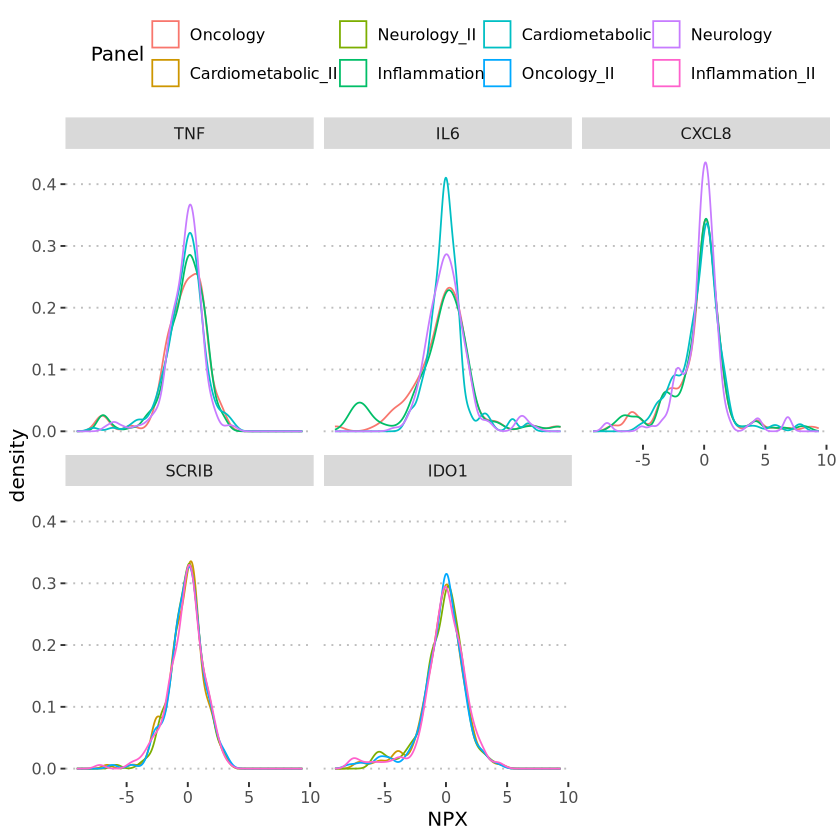

In [32]:
plate_duplicates <- c("TNF", "SCRIB", "IL6", "IDO1", "CXCL8")

data.batch1 %>% 
  filter(Assay %in% plate_duplicates) %>% 
  filter_samples() %>%
  select(Panel, NPX, Assay) %>% 
  ggplot() + geom_density(aes(NPX, color=Panel)) + facet_wrap(~Assay) +
  theme_pubclean() 

data.plate_duplicates.stats <- data.batch1 %>% 
  filter(Assay %in% plate_duplicates) %>% 
  filter_samples() %>%
  nest(data = -Assay) %>% 
  mutate(
    bartlett = map(data, ~tidy(with(.x, bartlett.test(NPX ~ Panel)))),
    levene = map(data, ~tidy(with(.x, leveneTest(NPX ~ Panel)))),
    aov_test = map(data, ~tidy(with(.x, aov(NPX ~ Panel)))),
    aov_welch = map(data, ~tidy(with(.x, oneway.test(NPX ~ Panel, var.equal = T)))),
    kruskal_test = map(data, ~tidy(with(.x, kruskal.test(NPX ~ Panel))))
  )
    
plate_duplicates.table <- data.plate_duplicates.stats %>%
  select(-data) %>%
  unnest(cols = c(bartlett, levene, aov_test, aov_welch, kruskal_test), names_sep = " ") %>%
  filter(`aov_test term` == "Panel") %>%
  select(Assay, `bartlett p.value`, `levene p.value`, `aov_test p.value`, `aov_welch p.value`, `kruskal_test p.value`) %>%
  gt() %>% 
    tab_header(title = "Statistics for plate duplicated assays") %>%
    fmt_number() %>%
    cols_align(align="center")
  
gt:::as.tags.gt_tbl(plate_duplicates.table)



It can be seen that the plate duplicated assays are very similar across plates. The only exception is IL-6 due to having a bimodal peak in the inflammation panel. Bartlett's and Leven's test indicate unequal variance for IL-6, and the more sensitive Bartlett also for TNF and CXCL6. There are no differences with anova except for IL-6. IL-6 does not show a difference either among plates with the non-parametric kruskal-wallis test. 

The column `Sample_Type` corresponds to samples with the prefix "control". 

In [33]:
technical_control <- ifelse(data.batch1[["Sample_Type"]] == "CONTROL", TRUE, FALSE)
data.batch1 <- data.batch1 %>%
    mutate(is_technical_control = grepl("control", SampleID, ignore.case = T))

all(technical_control == data.batch1[["is_technical_control"]])

[1] TRUE

# File Save
Save the file of bone marrow data as a csv for combining with plasma samples and control. Batch 1 and 2 saved separately since batch 2 is not used currently due to technical challenges. 

In [34]:
file.name = "BMIF_Olink_Samples_batch1.csv"
data.output.path <- file.path("../data", file.name)
data.output.path
dim(data.batch1)
table(data.batch1$Cohort)

[1] "../Data/BMIF_Olink_Samples_batch1.csv"

[1] 500310     24


AllCells      FH1 
   64746   423792 

In [35]:
write_excel_csv(data.batch1, data.output.path)

In [36]:
file.name = "BMIF_Olink_Samples_batch2.csv"
data.output.path <- file.path("../data", file.name)
data.output.path
dim(data.batch2)
write_excel_csv(data.batch2, data.output.path)
table(data.batch1$Cohort)

[1] "../Data/BMIF_Olink_Samples_batch2.csv"

[1] 214032     58


AllCells      FH1 
   64746   423792 

# HISE Checkpoint

In [37]:
project = 'FH_MM_Year4'
title <- paste("Intermediate BMIF Olink", Sys.Date())
in_files <- list('628523de-7712-4668-a93b-787d859be647',
                 '23e27aa1-0346-44a6-aa74-f9ddc3dee8c1')
currDir = getwd()
target_file <- "../../data/olink/BMIF_Olink_Samples_batch1.csv"                    
target_file
project
title
in_files

[1] "/home/workspace/2025-mm-project/Olink/Data/BMIF_Olink_Samples_batch1.csv"

[1] "FH_MM_Year4"

[1] "Intermediate BMIF Olink 2025-09-05"

[[1]]
[1] "628523de-7712-4668-a93b-787d859be647"

[[2]]
[1] "23e27aa1-0346-44a6-aa74-f9ddc3dee8c1"

In [34]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] patchwork_1.2.0       ComplexHeatmap_2.18.0 devtools_2.4.5       
 [4] usethis_3.0.0         OlinkAnalyze_4.3.1    logger_0.4.0         
 [7] knitr_1.50            gtsummary_2.3.0       gtExtras_0.6.0       
[10] gt_1.0.0              car_3.1-2             carData_3.0-5        
[13] broom_1.0.6